In [ ]:
!pip install -q ddgs ollama
!apt-get install -y zstd -qq
!curl -fsSL https://ollama.com/install.sh | sh
!pip install -q statsmodels


!pkill -f "ollama serve"
import time
time.sleep(2)

import subprocess, time

with open('/kaggle/working/ollama.log', 'w') as log_file:
    subprocess.Popen(['ollama', 'serve'], stdout=log_file, stderr=log_file)

time.sleep(5)
print("Service Ollama demarre")

# Gemma 3
#!ollama pull gemma3:1b
!ollama pull gemma3:4b
#!ollama pull gemma3:12b

# Qwen 2.5
#!ollama pull qwen2.5:1.5b
!ollama pull qwen2.5:7b
#!ollama pull qwen2.5:14b

# Llama 3.2
#!ollama pull llama3.2:1b
!ollama pull llama3.2:3b

# Phi-4
!ollama pull phi4-mini


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import csv
import random
import re
import time
import ollama
from ddgs import DDGS
from collections import Counter
from statsmodels.stats.contingency_tables import cochrans_q
from scipy.stats import chi2
import numpy as np
import os, datetime
from urllib.parse import urlparse

In [ ]:
!nvidia-smi

In [ ]:
def lire_csv(chemin):
    with open(chemin, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/echantillon-data/"
chemin_domaines = "/kaggle/input/datasets/imenec/domaines/"

chemin_out = "/kaggle/working/"

articles = lire_csv(chemin_in + "echantillon_150.csv")
domaines = lire_csv(chemin_domaines + "domaines_valides.csv")

print(f"Echantillon  : {len(articles)} articles")
print(f"Domaines  : {len(domaines)} domaines")


In [ ]:
def chercher_preuves(requete):
    # cherche sur web des infos sur le texte passé en param
    # retourne les 3 premiers resultats trouvés formatés en liste de points

    #requete = titre if titre else texte[:100]
    try:
        resultats = DDGS().text(requete, max_results=3)
    except Exception as e:
        print(f"  Erreur de recherche : {e}")
        return "(aucune preuve trouvee)"

    if not resultats:
        return "(aucune preuve trouvee)"

    morceaux = []
    for r in resultats:
        morceaux.append(f"- {r.get('title', '')} : {r.get('body', '')[:200]}")
    return "\n".join(morceaux)


In [ ]:
def chercher_preuves_2(requete, max_tentatives=3):
    # cherche sur web des infos sur le texte passé en param
    # retourne les 3 premiers resultats trouvés formatés en liste de points
    # difference avec l'autre, si on échoue a trouver des preuves, on essaye jusqu'a 3 tentatives


    for tentative in range(1, max_tentatives + 1):
        try:
            # timeout augmente a 20s (au lieu de 5s par defaut)
            with DDGS(timeout=20) as ddgs:
                resultats = ddgs.text(query=requete, max_results=3)

            if not resultats:
                return "(aucune preuve trouvee)", []

            morceaux = []
            domaines = []
            
            for r in resultats:
                morceaux.append(f"- {r.get('title', '')} : {r.get('body', '')[:200]}")
                domaines.append(urlparse(r.get("href", "")).netloc)
            return "\n".join(morceaux), domaines

        except Exception as e:
            print(f"  [!] Tentative {tentative}/{max_tentatives} echouee : {e}")
            if tentative < max_tentatives:
                # attend de plus en plus longtemps a chaque tentative (3s, 6s, 9s)
                time.sleep(3 * tentative)

    # si toutes les tentatives ont echoue
    return "(aucune preuve trouvee apres plusieurs tentatives)", []


In [ ]:
def construire_prompt(titre, texte, source, preuves, avec_rag):
    texte_court = texte[:800]

    prompt = "Voici un article a verifier.\n\n"
    if source != "":
        prompt = prompt + "Source : " + source + "\n"
    prompt = prompt + "Titre : " + titre + "\n"
    prompt = prompt + "Texte : " + texte_court + "\n\n"

    if avec_rag:
        prompt = prompt + "Preuves trouvees sur le web concernant cette affirmation :\n"
        prompt = prompt + preuves + "\n\n"
        prompt = prompt + "En te basant sur ces preuves, verifie si l'affirmation de cet article est vraie ou fausse.\n"
    else:
        prompt = prompt + "En te basant sur ce que tu connais déja, verifie si l'affirmation de cet article est vraie ou fausse.\n"
    
    prompt = prompt + "Reponds uniquement par un seul mot : \"fake\" ou \"real\"."

    return prompt


def extraire_verdict(reponse_llm):
    texte = reponse_llm.lower().strip()

    contient_fake = bool(re.search(r"\bfake\b", texte))
    contient_real = bool(re.search(r"\breal\b", texte))

    # uniquemnt fake
    if contient_fake and not contient_real:
        return "fake"

    # uniquemnt real
    if contient_real and not contient_fake:
        return "real"

    # sinon
    return "indetermine"

In [ ]:
def demander_verdict(titre, texte, source, preuves, avec_rag):

    prompt = construire_prompt(titre, texte, source, preuves, avec_rag)

    #reponse = ollama.chat(model=m, messages=[{"role": "user", "content": prompt}])

    reponse = ollama.chat(
        model=m,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )

    contenu = reponse["message"]["content"]

    return extraire_verdict(contenu)


In [ ]:
FICHIER_PREUVES = chemin_out + "preuves_150.csv"

def sauver_preuve(id_article, requete, preuves, domaines):
    nouveau = not os.path.exists(FICHIER_PREUVES)
    with open(FICHIER_PREUVES, "a", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        if nouveau:
            w.writerow(["id", "requete", "Preuves", "domaine", "date_recherche"])
        w.writerow([id_article, requete, preuves, " | ".join(domaines), datetime.date.today().isoformat()])

In [ ]:
def nettoyer_requete2(titre):
    # enlève les noms de sites de fact-checking qui revelent la source
    titre = re.sub(r"gossip\s*cop|politi\s*fact|snopes", "", titre, flags=re.IGNORECASE)
    titre = re.sub(r"\s+", " ", titre)      #espaces en double
    return titre.strip(" -|:–—")              # tirets ou deux-points restes aux bords

In [ ]:
def nom_media2(domaine):
    domaine = domaine.lower()
    domaine = domaine.replace("www.", "")
    return domaine.split(".")[0]

In [ ]:
def tester_contrefactuel(article, source, avec_rag, creer_preuves):

    titre = article.get("title", "")
    texte = article.get("text", "")
    vraie_source = article.get("domaine", "source inconnue")
    vrai_label = article.get("label", "")

    # RAG ou non-RAG
    if avec_rag:
        if creer_preuves:
            requete = titre if titre else texte[:100]
            preuves, domaines_rag = chercher_preuves_2(requete)

            # Sauvegarde en memoire
            article["preuves"] = preuves

            # Sauvegarde dans le fichier CSV
            sauver_preuve(article["id"], requete, preuves, domaines_rag)
            print(f"RAG CRÉÉ pour : {article.get('id', '')}")

        else:
            # reutilisation des memes preuves
            preuves = article["preuves"]
            print(f"RAG RÉUTILISÉ pour : {article.get('id', '')}")

    else:
        preuves = None

    # Un seul verdict, avec la source pass en paramètre
    verdict = demander_verdict(titre, texte, source, preuves, avec_rag)

    return {
        "id": article.get("id", ""),
        "vraie_source": vraie_source,
        "vrai_label": vrai_label,
        "source_testee": source,
        "verdict": verdict
    }

In [ ]:
def lancer_test_contrefactuel(echantillon, chemin_sortie, source, avec_rag, creer_preuves):

    colonnes = ["id", "vraie_source", "vrai_label", "source_testee", "verdict"]
    resultats = []

    with open(chemin_sortie, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=colonnes)
        writer.writeheader()

        for i, article in enumerate(echantillon):
            r = tester_contrefactuel(article, source, avec_rag, creer_preuves)
            writer.writerow(r)
            resultats.append(r)
            print(f"[{i+1}/{len(echantillon)}] OK")

    return resultats

In [ ]:
random.seed(30)
domaines = [d["domaine_principal"] for d in domaines]
sources = random.sample(domaines, 5)


MODS = ["gemma3:4b", "qwen2.5:7b", "llama3.2:3b", "phi4-mini"]

MODELES = ["gemma3:4b", "gemma3:1b", "gemma3:12b",
           "qwen2.5:1.5b", "qwen2.5:7b", "qwen2.5:14b",
           "llama3.2:1b", "llama3.2:3b", "phi4-mini"]

sources.append("") # ajouter la sans source a nos 5 sources

preuve = True # True seulement pour le tout premier passage avec RAG

for m in MODS:
    nom = m.replace(":", "_")

    for avec_rag in (True, False):
        mode = "RAG" if avec_rag else "WRAG"
        print("====================", mode, ":", m, "====================")

        for j, source in enumerate(sources):
            lancer_test_contrefactuel(echantillon=articles,
                                      chemin_sortie=chemin_out + "_" + source +"_" + nom + "_" + mode + ".csv",
                                      source=source,
                                      avec_rag=avec_rag,
                                      creer_preuves=(preuve and avec_rag and j == 0))

    preuve = False

12 fichiers trouvés

Résultats :


Configuration,Avec RAG,Sans RAG
Source,,
Sans source,73.33,82.00
beautycrew.com.au,74.67,83.33
bravotv.com,74.67,85.33
justjaredjr.com,74.67,84.67
modeglam.com,76.67,84.00
newslocker.com,72.67,80.67


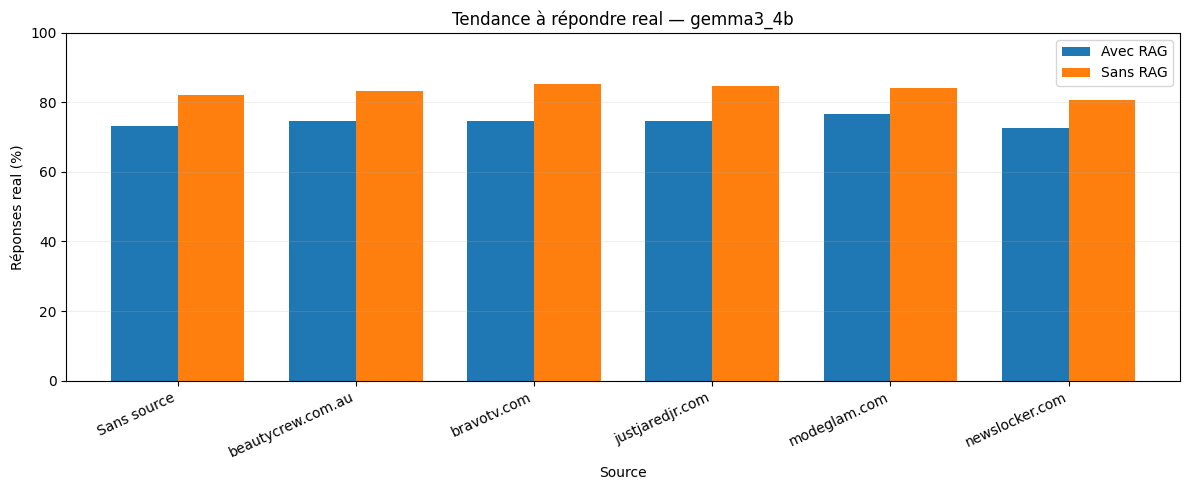

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Configuration
MODELE = "gemma3_4b"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat-gemma/")
COLONNE_VERDICT = "verdict"

# 2. Récupérer les fichiers CSV
fichiers = sorted(DOSSIER.glob(f"*_{MODELE}_*.csv"))

print(f"{len(fichiers)} fichiers trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun CSV trouvé dans {DOSSIER} pour {MODELE}"
    )

# 3. Calculer le taux de réponses real
resultats = []

for fichier in fichiers:

    nom = fichier.stem

    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    df = pd.read_csv(fichier)

    if COLONNE_VERDICT not in df.columns:
        raise ValueError(
            f"Colonne '{COLONNE_VERDICT}' introuvable. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    verdicts = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    taux_real = (verdicts == "real").mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real
    })

# 4. Préparer les données du graphique
resultats = pd.DataFrame(resultats)

tableau = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

print("\nRésultats :")
display(tableau.round(2))

# 5. Générer UN SEUL graphique à barres
ax = tableau.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers CSV trouvés

Résultats du modèle : gemma3_4b


,Source,Configuration,Taux real (%),Accuracy (%)
0,beautycrew.com.au,Avec RAG,74.67,67.33
1,beautycrew.com.au,Sans RAG,83.33,61.33
2,bravotv.com,Avec RAG,74.67,67.33
3,bravotv.com,Sans RAG,85.33,60.67
4,justjaredjr.com,Avec RAG,74.67,68.67
5,justjaredjr.com,Sans RAG,84.67,62.67
6,modeglam.com,Avec RAG,76.67,68.00
7,modeglam.com,Sans RAG,84.00,63.33
8,newslocker.com,Avec RAG,72.67,66.67
9,newslocker.com,Sans RAG,80.67,62.67


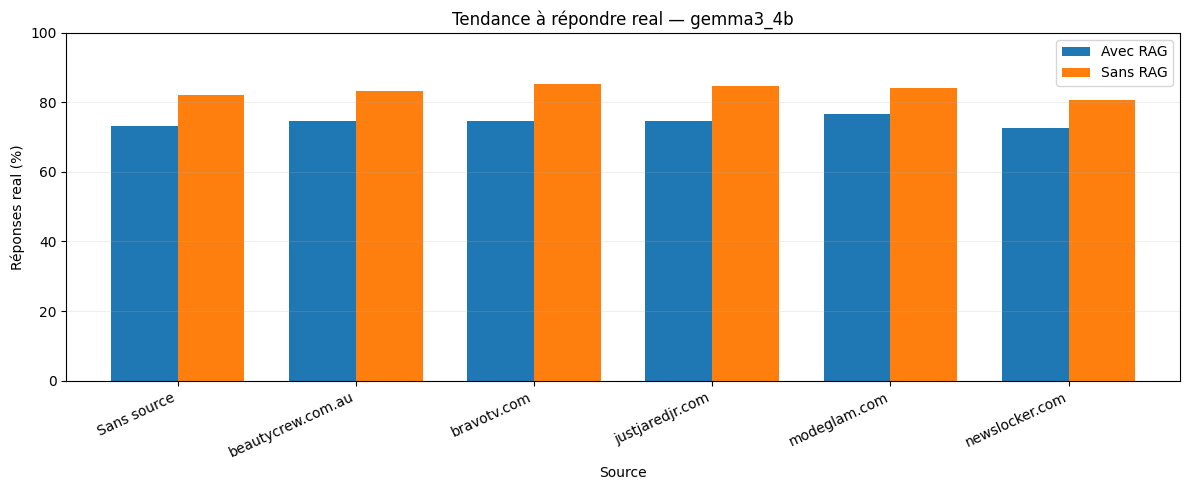

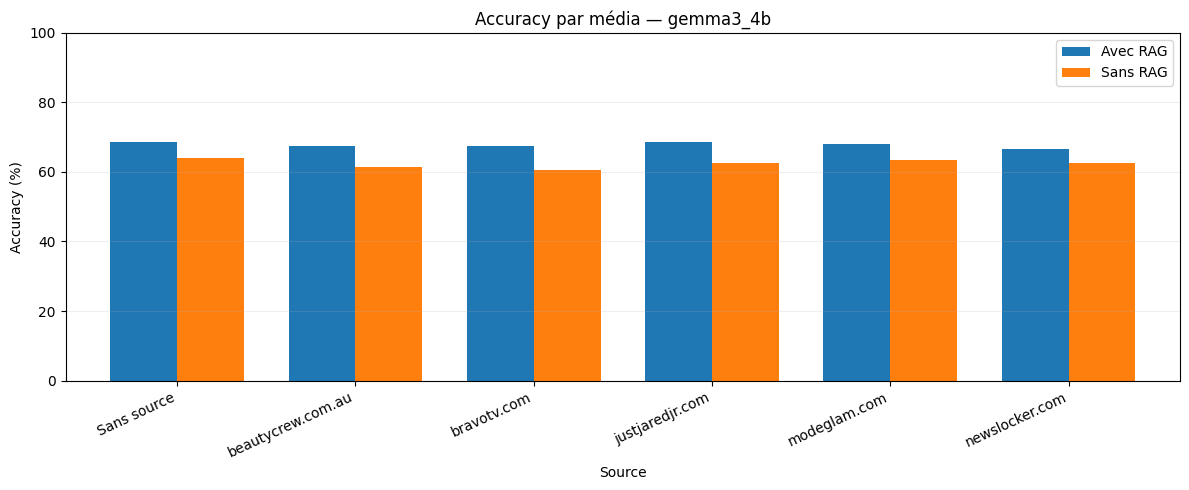

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. CONFIGURATION
# ==========================================

MODELE = "gemma3_4b"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat_gemma/")

COLONNE_LABEL = "vrai_label"
COLONNE_VERDICT = "verdict"

# ==========================================
# 2. RÉCUPÉRER LES FICHIERS CSV
# ==========================================

# Chercher les CSV du modèle dans tous les dossiers Kaggle
fichiers = sorted([
    f for f in Path("/kaggle/input").rglob("*.csv")
    if f"_{MODELE}_" in f.name
])

print(f"{len(fichiers)} fichiers CSV trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun fichier trouvé pour {MODELE} dans {DOSSIER}"
    )

# ==========================================
# 3. CALCULER LES INDICATEURS
# ==========================================

resultats = []

for fichier in fichiers:

    nom = fichier.stem

    # Identifier la configuration
    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    # Identifier la source
    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    # Lire le CSV
    df = pd.read_csv(fichier)

    # Vérifier les colonnes
    colonnes_requises = [COLONNE_LABEL, COLONNE_VERDICT]

    for colonne in colonnes_requises:
        if colonne not in df.columns:
            raise ValueError(
                f"Colonne '{colonne}' introuvable dans {fichier.name}. "
                f"Colonnes disponibles : {df.columns.tolist()}"
            )

    # Normaliser les valeurs
    vrais_labels = (
        df[COLONNE_LABEL]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    predictions = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Vérifier les valeurs
    valides = (
        vrais_labels.isin(["fake", "real"])
        & predictions.isin(["fake", "real"])
    )

    if not valides.all():
        raise ValueError(
            f"Valeurs invalides dans {fichier.name}. "
            "Les labels et prédictions doivent être 'fake' ou 'real'."
        )

    # Taux de réponses real
    taux_real = (predictions == "real").mean() * 100

    # Accuracy
    accuracy = (predictions == vrais_labels).mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real,
        "Accuracy (%)": accuracy
    })

# ==========================================
# 4. AFFICHER LES RÉSULTATS
# ==========================================

resultats = pd.DataFrame(resultats)

if resultats.empty:
    raise ValueError("Aucun résultat exploitable.")

print("\nRésultats du modèle :", MODELE)
display(resultats.round(2))

# ==========================================
# 5. GRAPHIQUE : TAUX DE RÉPONSES REAL
# ==========================================

tableau_real = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

ax = tableau_real.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ==========================================
# 6. GRAPHIQUE : ACCURACY
# ==========================================

tableau_accuracy = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Accuracy (%)"
)

ax = tableau_accuracy.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Accuracy par média — {MODELE}")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers trouvés

Résultats :


Configuration,Avec RAG,Sans RAG
Source,,
Sans source,56.67,52.67
beautycrew.com.au,56.67,43.33
bravotv.com,57.33,52.00
justjaredjr.com,57.33,54.67
modeglam.com,51.33,40.00
newslocker.com,44.00,34.00


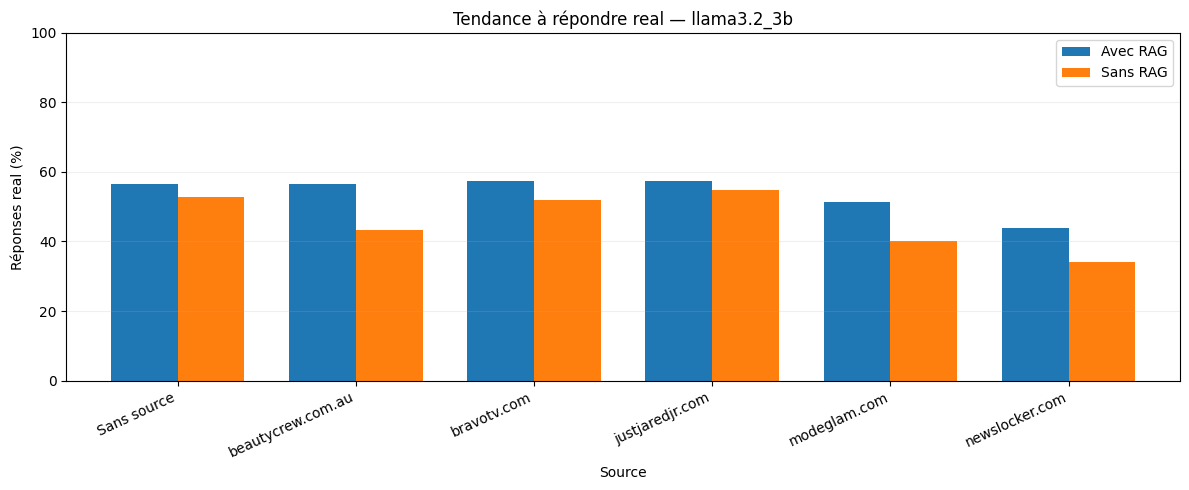

In [6]:

# 1. Configuration
MODELE = "llama3.2_3b"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat-llama/")
COLONNE_VERDICT = "verdict"

# 2. Récupérer les fichiers CSV
fichiers = sorted(DOSSIER.glob(f"*_{MODELE}_*.csv"))

print(f"{len(fichiers)} fichiers trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun CSV trouvé dans {DOSSIER} pour {MODELE}"
    )

# 3. Calculer le taux de réponses real
resultats = []

for fichier in fichiers:

    nom = fichier.stem

    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    df = pd.read_csv(fichier)

    if COLONNE_VERDICT not in df.columns:
        raise ValueError(
            f"Colonne '{COLONNE_VERDICT}' introuvable. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    verdicts = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    taux_real = (verdicts == "real").mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real
    })

# 4. Préparer les données du graphique
resultats = pd.DataFrame(resultats)

tableau = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

print("\nRésultats :")
display(tableau.round(2))

# 5. Générer UN SEUL graphique à barres
ax = tableau.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers trouvés

Résultats :


Configuration,Avec RAG,Sans RAG
Source,,
Sans source,46.67,72.67
beautycrew.com.au,44.67,74.67
bravotv.com,46.00,76.00
justjaredjr.com,44.67,64.00
modeglam.com,45.33,72.00
newslocker.com,48.67,75.33


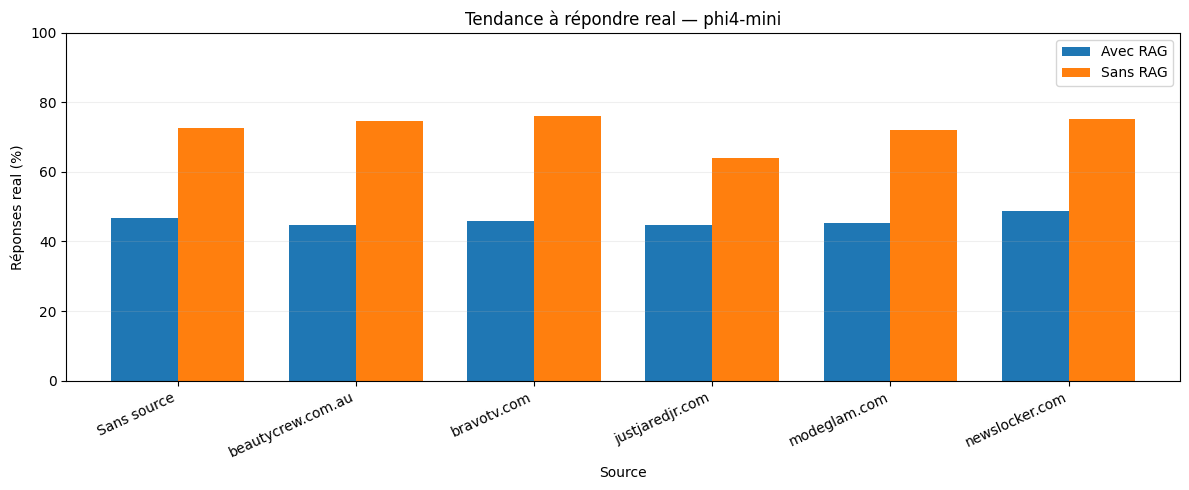

In [12]:

# 1. Configuration
MODELE = "phi4-mini"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat-phi4/")
COLONNE_VERDICT = "verdict"

# 2. Récupérer les fichiers CSV
fichiers = sorted(DOSSIER.glob(f"*_{MODELE}_*.csv"))

print(f"{len(fichiers)} fichiers trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun CSV trouvé dans {DOSSIER} pour {MODELE}"
    )

# 3. Calculer le taux de réponses real
resultats = []

for fichier in fichiers:

    nom = fichier.stem

    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    df = pd.read_csv(fichier)

    if COLONNE_VERDICT not in df.columns:
        raise ValueError(
            f"Colonne '{COLONNE_VERDICT}' introuvable. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    verdicts = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    taux_real = (verdicts == "real").mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real
    })

# 4. Préparer les données du graphique
resultats = pd.DataFrame(resultats)

tableau = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

print("\nRésultats :")
display(tableau.round(2))

# 5. Générer UN SEUL graphique à barres
ax = tableau.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers CSV trouvés

Résultats du modèle : phi4-mini


,Source,Configuration,Taux real (%),Accuracy (%)
0,beautycrew.com.au,Avec RAG,44.67,65.33
1,beautycrew.com.au,Sans RAG,74.67,59.33
2,bravotv.com,Avec RAG,46.00,62.67
3,bravotv.com,Sans RAG,76.00,58.00
4,justjaredjr.com,Avec RAG,44.67,65.33
5,justjaredjr.com,Sans RAG,64.00,62.00
6,modeglam.com,Avec RAG,45.33,64.67
7,modeglam.com,Sans RAG,72.00,60.67
8,newslocker.com,Avec RAG,48.67,66.67
9,newslocker.com,Sans RAG,75.33,56.00


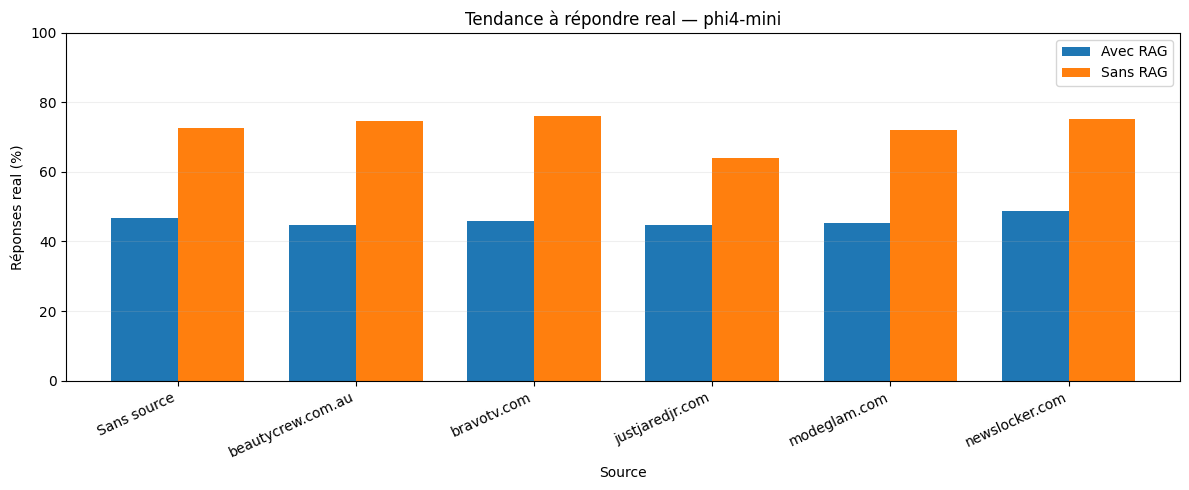

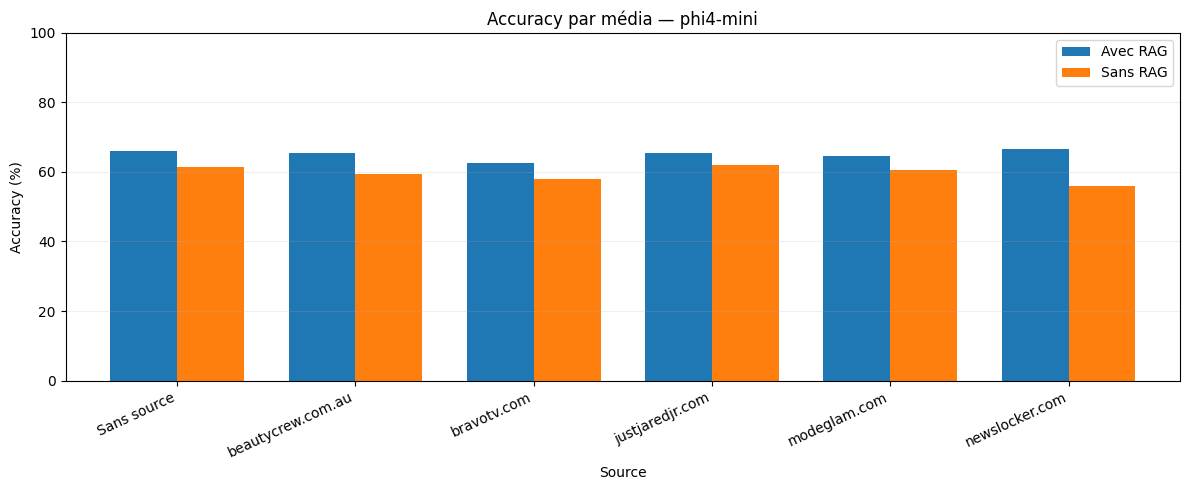

In [7]:


# ==========================================
# 1. CONFIGURATION
# ==========================================

MODELE = "phi4-mini"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat_phi4/")

COLONNE_LABEL = "vrai_label"
COLONNE_VERDICT = "verdict"

# ==========================================
# 2. RÉCUPÉRER LES FICHIERS CSV
# ==========================================

# Chercher les CSV du modèle dans tous les dossiers Kaggle
fichiers = sorted([
    f for f in Path("/kaggle/input").rglob("*.csv")
    if f"_{MODELE}_" in f.name
])

print(f"{len(fichiers)} fichiers CSV trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun fichier trouvé pour {MODELE} dans {DOSSIER}"
    )

# ==========================================
# 3. CALCULER LES INDICATEURS
# ==========================================

resultats = []

for fichier in fichiers:

    nom = fichier.stem

    # Identifier la configuration
    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    # Identifier la source
    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    # Lire le CSV
    df = pd.read_csv(fichier)

    # Vérifier les colonnes
    colonnes_requises = [COLONNE_LABEL, COLONNE_VERDICT]

    for colonne in colonnes_requises:
        if colonne not in df.columns:
            raise ValueError(
                f"Colonne '{colonne}' introuvable dans {fichier.name}. "
                f"Colonnes disponibles : {df.columns.tolist()}"
            )

    # Normaliser les valeurs
    vrais_labels = (
        df[COLONNE_LABEL]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    predictions = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Vérifier les valeurs
    valides = (
        vrais_labels.isin(["fake", "real"])
        & predictions.isin(["fake", "real"])
    )

    if not valides.all():
        raise ValueError(
            f"Valeurs invalides dans {fichier.name}. "
            "Les labels et prédictions doivent être 'fake' ou 'real'."
        )

    # Taux de réponses real
    taux_real = (predictions == "real").mean() * 100

    # Accuracy
    accuracy = (predictions == vrais_labels).mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real,
        "Accuracy (%)": accuracy
    })

# ==========================================
# 4. AFFICHER LES RÉSULTATS
# ==========================================

resultats = pd.DataFrame(resultats)

if resultats.empty:
    raise ValueError("Aucun résultat exploitable.")

print("\nRésultats du modèle :", MODELE)
display(resultats.round(2))

# ==========================================
# 5. GRAPHIQUE : TAUX DE RÉPONSES REAL
# ==========================================

tableau_real = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

ax = tableau_real.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ==========================================
# 6. GRAPHIQUE : ACCURACY
# ==========================================

tableau_accuracy = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Accuracy (%)"
)

ax = tableau_accuracy.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Accuracy par média — {MODELE}")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers trouvés

Résultats :


Configuration,Avec RAG,Sans RAG
Source,,
Sans source,57.33,28.67
beautycrew.com.au,58.67,29.33
bravotv.com,57.33,32.00
justjaredjr.com,58.00,36.00
modeglam.com,57.33,30.00
newslocker.com,58.67,28.00


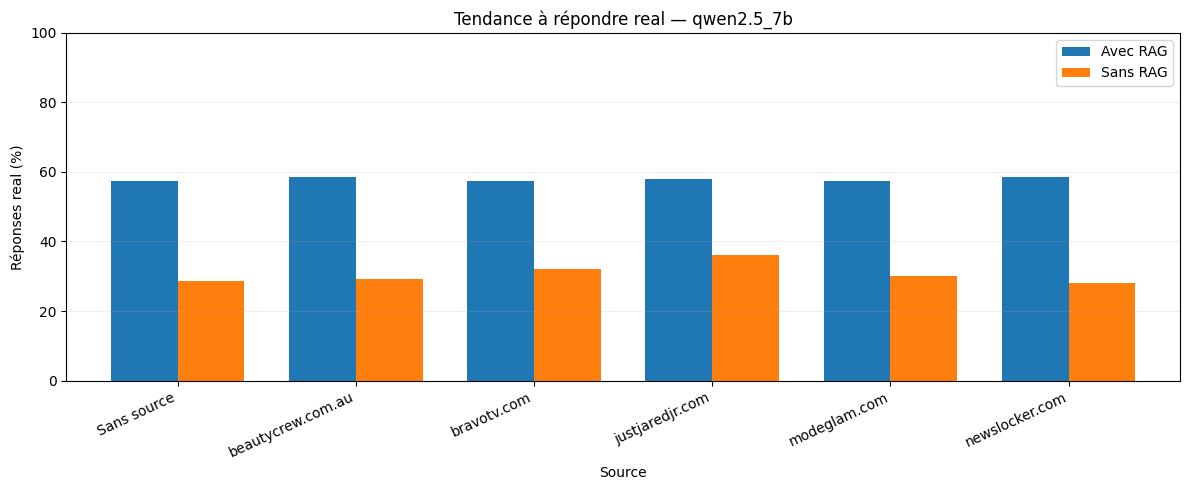

In [13]:

# 1. Configuration
MODELE = "qwen2.5_7b"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat-qwen/")
COLONNE_VERDICT = "verdict"

# 2. Récupérer les fichiers CSV
fichiers = sorted(DOSSIER.glob(f"*_{MODELE}_*.csv"))

print(f"{len(fichiers)} fichiers trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun CSV trouvé dans {DOSSIER} pour {MODELE}"
    )

# 3. Calculer le taux de réponses real
resultats = []

for fichier in fichiers:

    nom = fichier.stem

    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    df = pd.read_csv(fichier)

    if COLONNE_VERDICT not in df.columns:
        raise ValueError(
            f"Colonne '{COLONNE_VERDICT}' introuvable. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    verdicts = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    taux_real = (verdicts == "real").mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real
    })

# 4. Préparer les données du graphique
resultats = pd.DataFrame(resultats)

tableau = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

print("\nRésultats :")
display(tableau.round(2))

# 5. Générer UN SEUL graphique à barres
ax = tableau.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


12 fichiers CSV trouvés

Résultats du modèle : qwen2.5_7b


,Source,Configuration,Taux real (%),Accuracy (%)
0,beautycrew.com.au,Avec RAG,58.67,70.00
1,beautycrew.com.au,Sans RAG,29.33,62.00
2,bravotv.com,Avec RAG,57.33,70.00
3,bravotv.com,Sans RAG,32.00,68.67
4,justjaredjr.com,Avec RAG,58.00,70.67
5,justjaredjr.com,Sans RAG,36.00,70.00
6,modeglam.com,Avec RAG,57.33,68.67
7,modeglam.com,Sans RAG,30.00,69.33
8,newslocker.com,Avec RAG,58.67,70.00
9,newslocker.com,Sans RAG,28.00,64.67


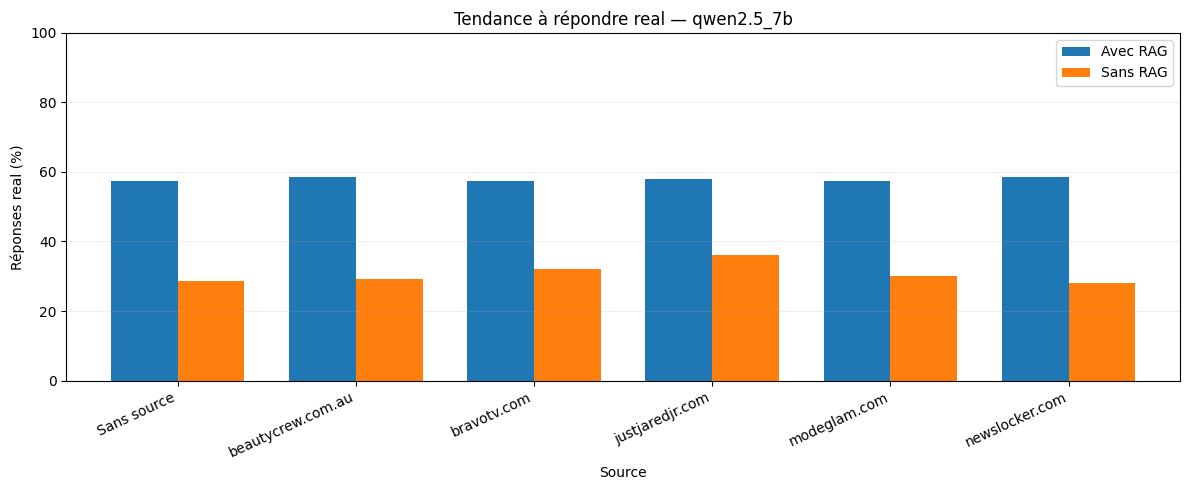

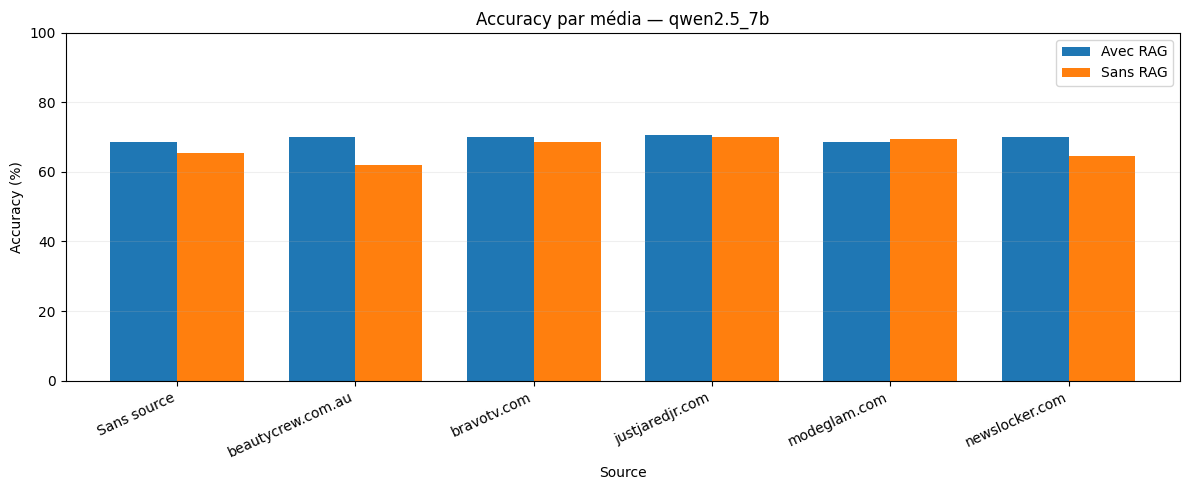

In [8]:


# ==========================================
# 1. CONFIGURATION
# ==========================================

MODELE = "qwen2.5_7b"
DOSSIER = Path("/kaggle/input/datasets/imenec/resultat_qwen/")

COLONNE_LABEL = "vrai_label"
COLONNE_VERDICT = "verdict"

# ==========================================
# 2. RÉCUPÉRER LES FICHIERS CSV
# ==========================================

# Chercher les CSV du modèle dans tous les dossiers Kaggle
fichiers = sorted([
    f for f in Path("/kaggle/input").rglob("*.csv")
    if f"_{MODELE}_" in f.name
])

print(f"{len(fichiers)} fichiers CSV trouvés")

if not fichiers:
    raise FileNotFoundError(
        f"Aucun fichier trouvé pour {MODELE} dans {DOSSIER}"
    )

# ==========================================
# 3. CALCULER LES INDICATEURS
# ==========================================

resultats = []

for fichier in fichiers:

    nom = fichier.stem

    # Identifier la configuration
    if nom.endswith("_WRAG"):
        configuration = "Sans RAG"
        source = nom.removesuffix(f"_{MODELE}_WRAG")

    elif nom.endswith("_RAG"):
        configuration = "Avec RAG"
        source = nom.removesuffix(f"_{MODELE}_RAG")

    else:
        continue

    # Identifier la source
    source = source.lstrip("_")

    if source == "sansSource":
        source = "Sans source"

    # Lire le CSV
    df = pd.read_csv(fichier)

    # Vérifier les colonnes
    colonnes_requises = [COLONNE_LABEL, COLONNE_VERDICT]

    for colonne in colonnes_requises:
        if colonne not in df.columns:
            raise ValueError(
                f"Colonne '{colonne}' introuvable dans {fichier.name}. "
                f"Colonnes disponibles : {df.columns.tolist()}"
            )

    # Normaliser les valeurs
    vrais_labels = (
        df[COLONNE_LABEL]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    predictions = (
        df[COLONNE_VERDICT]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Vérifier les valeurs
    valides = (
        vrais_labels.isin(["fake", "real"])
        & predictions.isin(["fake", "real"])
    )

    if not valides.all():
        raise ValueError(
            f"Valeurs invalides dans {fichier.name}. "
            "Les labels et prédictions doivent être 'fake' ou 'real'."
        )

    # Taux de réponses real
    taux_real = (predictions == "real").mean() * 100

    # Accuracy
    accuracy = (predictions == vrais_labels).mean() * 100

    resultats.append({
        "Source": source,
        "Configuration": configuration,
        "Taux real (%)": taux_real,
        "Accuracy (%)": accuracy
    })

# ==========================================
# 4. AFFICHER LES RÉSULTATS
# ==========================================

resultats = pd.DataFrame(resultats)

if resultats.empty:
    raise ValueError("Aucun résultat exploitable.")

print("\nRésultats du modèle :", MODELE)
display(resultats.round(2))

# ==========================================
# 5. GRAPHIQUE : TAUX DE RÉPONSES REAL
# ==========================================

tableau_real = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Taux real (%)"
)

ax = tableau_real.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Tendance à répondre real — {MODELE}")
ax.set_ylabel("Réponses real (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ==========================================
# 6. GRAPHIQUE : ACCURACY
# ==========================================

tableau_accuracy = resultats.pivot(
    index="Source",
    columns="Configuration",
    values="Accuracy (%)"
)

ax = tableau_accuracy.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)

ax.set_title(f"Accuracy par média — {MODELE}")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
ax.legend(title="")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


**TEST COCHRAN**


In [ ]:
def calcul_cochran_q(chemin_csv, nom, col_connu, col_peu_connu, col_anonyme):
    articles = lire_csv(chemin_csv)

    tab=[]
    for a in articles:
        if a[col_connu] == "real":
            connu = 1
        else:
            connu = 0

        if a[col_peu_connu] == "real":
            peu_connu = 1
        else:
            peu_connu = 0

        if a[col_anonyme] == "real":
            anonyme = 1
        else:
            anonyme = 0

        tab.append([connu, peu_connu, anonyme])
        
    resultat = cochrans_q(tab)

    print(f"=== {nom} ===")
    print(f"  Statistique Q : {resultat.statistic:.2f}")
    print(f"  p-value : {resultat.pvalue:.2e}")

    if resultat.pvalue < 0.001:
        print("  => Les 3 conditions different significativement entre elles (p<0.001)")
    else:
        print("  => Pas de difference significative globale")
    print()

    return resultat
    

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/"

resultat_B_avecRAG = calcul_cochran_q(
    chemin_csv=chemin_in + "qwen_B_RAG.csv",
    nom="Categorie B (avec RAG)",
    col_connu="verdict_original",
    col_peu_connu="verdict_oppose",
    col_anonyme="verdict_anonyme"
)

resultat_D_avecRAG = calcul_cochran_q(
    chemin_csv=chemin_in + "qwen_D_RAG.csv",
    nom="Categorie D (avec RAG)",
    col_connu="verdict_oppose",
    col_peu_connu="verdict_original",
    col_anonyme="verdict_anonyme"
)

resultat_B_sansRAG = calcul_cochran_q(
    chemin_csv=chemin_in + "qwen_B_WRAG.csv",
    nom="Categorie B (sans RAG)",
    col_connu="verdict_original",
    col_peu_connu="verdict_oppose",
    col_anonyme="verdict_anonyme"
)

resultat_D_sansRAG = calcul_cochran_q(
    chemin_csv=chemin_in + "qwen_D_WRAG.csv",
    nom="Categorie D (sans RAG)",
    col_connu="verdict_oppose",
    col_peu_connu="verdict_original",
    col_anonyme="verdict_anonyme"
)

**Test mcneamar**

In [ ]:
 
def comparer_deux_colonnes(chemin_csv, nom_colonne_1, nom_colonne_2):
    # cette fonction compare 2 colonnes dun fichier csv avec le test mcNeamar
    # la fonction retourne un dictionnaire avec b, c, p-value,
    # proportions "real" de chaque colonne, diff + IC95%
    # b: nb d'articles "real" (colonne 1) devenus "fake" (colonne 2)
    # c: nb d'articles "fake" (colonne 1) devenus "real" (colonne 2)
    # p_value: probabilite d'observer ce desequilibre entre b et c
    # p_real_colonne_1: proportion d'articles "real" dans la colonne 1
    # p_real_colonne_2: proportion d'articles "real" dans la colonne 2
    # diff_proportions: variation de la proportion de "real" (colonne_2 - colonne_1)
    # ic95_low/high:(95% de confiance) la plus petite et la plus grande valeur probable de la "vraie" difference
 
    col1, col2 = [], []
    with open(chemin_csv, newline="", encoding="utf-8") as f:
        for ligne in csv.DictReader(f):
            col1.append(ligne[nom_colonne_1].strip().lower())
            col2.append(ligne[nom_colonne_2].strip().lower())
 
    n = len(col1)
 
    table = {"fake_fake": 0, "fake_real": 0, "real_fake": 0, "real_real": 0}
    for a, b_ in zip(col1, col2):
        table[f"{a}_{b_}"] += 1
 
    b = table["real_fake"]   # col1=real, col2=fake 
    c = table["fake_real"]   # col1=fake, col2=real
    nbr_flip = b + c
 
    # mcnemar
    if nbr_flip == 0:
        stat, p = 0.0, 1.0
    else:
        stat = (abs(b - c) - 1) ** 2 / nbr_flip
        p = 1 - chi2.cdf(stat, df=1)
 
    # proportions + IC95% de la difference appariee
    p1 = col1.count("real") / n #proportion d'articles "real" dans la colonne 1
    p2 = col2.count("real") / n #proportion d'articles "real" dans la colonne 2
    
    diff = p2 - p1
    
    se = ((b + c) - (b - c) ** 2 / n) ** 0.5 / n
    ic_low, ic_high = diff - 1.96 * se, diff + 1.96 * se
 
    return {
        "colonne_1": nom_colonne_1,
        "colonne_2": nom_colonne_2,
        "b_real_to_fake": b,
        "c_fake_to_real": c,
        "p_value": p,
        "p_real_colonne_1": p1,
        "p_real_colonne_2": p2,
        "diff_proportions": diff,
        "ic95_low": ic_low,
        "ic95_high": ic_high,
    }

In [ ]:
 
def afficher_resultat(res, alpha=0.05/3):
    #Afficher les resultats de comparer_deux_colonnes() de facon lisible
    
    print(f"Comparaison : {res['colonne_1']} vs {res['colonne_2']}")
    print(f"  b (real->fake) = {res['b_real_to_fake']}, c (fake->real) = {res['c_fake_to_real']}, "
          f"changements = {res['b_real_to_fake'] + res['c_fake_to_real']}")
    print(f"  McNemar : p = {res['p_value']:.4g} "
          f"-> {'significatif' if res['p_value'] < alpha else 'non significatif'} (alpha={alpha})")
    print(f"  Proportion 'real' : {res['p_real_colonne_1']*100:.1f}% -> {res['p_real_colonne_2']*100:.1f}%")
    print(f"  Difference = {res['diff_proportions']*100:+.1f} points, "
          f"IC95% = [{res['ic95_low']*100:+.1f} ; {res['ic95_high']*100:+.1f}]")
    print()
 

 

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/gemma_B_RAG.csv"
print("Gemma sur catégorie B avec RAG")
# cat B , original = connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_oppose")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/gemma_B_WRAG.csv"
print("Gemma sur catégorie B sans RAG")
# cat B , original = connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_oppose")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/gemma_D_RAG.csv"
print("Gemma sur catégorie D avec RAG")
# cat D , original = peu connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_original")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/gemma_D_WRAG.csv"
print("Gemma sur catégorie D sans RAG")
# cat D , original = peu connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_original")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/qwen_B_RAG.csv"
print("Qwen sur catégorie B avec RAG")
# cat B , original = connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_oppose")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/qwen_B_WRAG.csv"
print("Qwen sur catégorie B sans RAG")
# cat B , original = connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_oppose")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/qwen_D_RAG.csv"
print("Qwen sur catégorie D avec RAG")
# cat D , original = peu connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_original")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res3)

In [ ]:
chemin_in = "/kaggle/input/datasets/imenec/experiences-results/qwen_D_WRAG.csv"
print("Qwen sur catégorie D sans RAG")
# cat D , original = peu connu
# connu vs peu_conu
res1 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_original")
afficher_resultat(res1)

# peu_connu vs anonyme
res2 = comparer_deux_colonnes(chemin_in, "verdict_original", "verdict_anonyme")
afficher_resultat(res2)

# connu vs anonyme
res3 = comparer_deux_colonnes(chemin_in, "verdict_oppose", "verdict_anonyme")
afficher_resultat(res3)